这个文档是用云模型拟合得到CHASE上观测到喷流的多普勒速度

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob
from scipy.io import readsav
from scipy.ndimage import zoom

In [4]:
with open('/share/home/xincheng/sjh/20241003_4/nlfff/nlfff_boundary/nlfff_boundary.dat', 'rb') as f:
    # 读取 nx1 和 nx2
    nx, ny = np.fromfile(f, dtype=np.int32, count=2)
    xc,yc = np.fromfile(f, dtype=np.float64, count=2)
    dx, dy = np.fromfile(f, dtype=np.float64, count=2)

FileNotFoundError: [Errno 2] No such file or directory: '/share/home/xincheng/sjh/20241003_4/nlfff/nlfff_boundary/nlfff_boundary.dat'

先保存一下目标区域的data

In [3]:
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\*.fits')

In [5]:
rsm=fits.open(file_list[0])
print(rsm[1].header['DATE_OBS'])

2024-06-18T21:17:11


In [8]:
data_chase=np.zeros((212,212,25))
for i in range(25):
    rsm=fits.open(file_list[i])
    hawing=rsm[1].data[-10,:,:]
    coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = rsm[1].header['DATE_OBS'], 
                         observer = 'earth', frame = frames.Helioprojective)
    headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
    hawing_map = sunpy.map.Map(hawing, headerwing)
    left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
    top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
    sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)
    data=sub_hawing_map.data
    if data.shape[0]!= 212 or data.shape[1]!= 212:
        data=zoom(data,(212/data.shape[0],212/data.shape[1]),order=1)
    data_chase[:,:,i]=data
    print(i)
np.save('data_chase.npy',data_chase)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


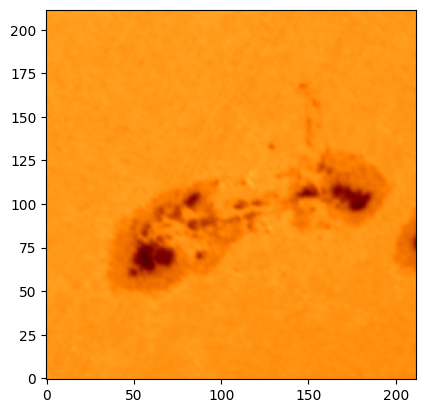

In [11]:
plt.imshow(data_chase[:,:,3],origin='lower',cmap='afmhot',vmin=0,vmax=2000)

In [13]:
a=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\result_matrix.npy')

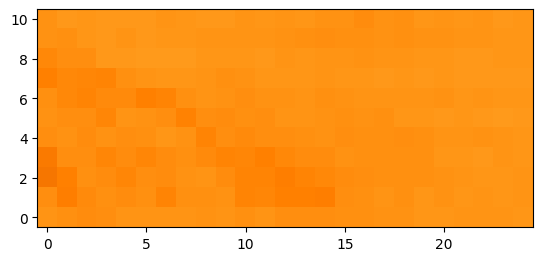

In [14]:
plt.imshow(a,cmap='afmhot',vmin=0,vmax=2000,origin='lower')

讨论了一下就不画CHASE的时距图了，效果不好，只画光谱曲线

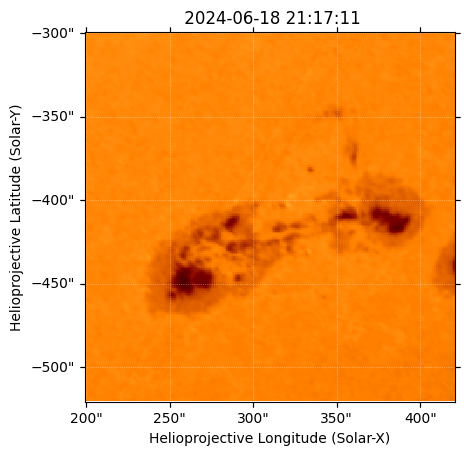

In [2]:
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
hawing = rsm[1].data[-10, :, :]
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)
fig = plt.figure()
left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)
sub_hawing_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hawing_map.data.mean() )

plt.show()

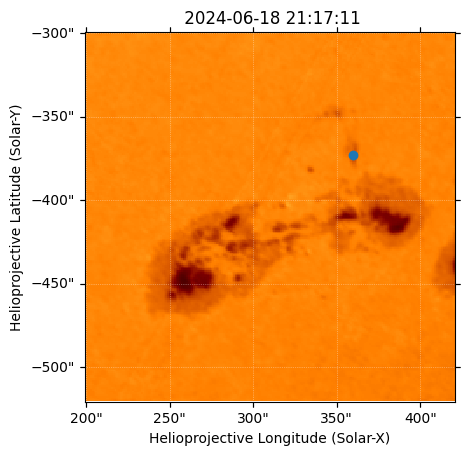

In [7]:
point=SkyCoord(Tx=360*u.arcsec,Ty=-373*u.arcsec,frame=hawing_map.coordinate_frame)
fig=plt.figure()
ax=plt.subplot(projection=sub_hawing_map)
sub_hawing_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hawing_map.data.mean() )
ax.plot_coord(point,marker='o')

In [15]:
point = SkyCoord(Tx=360*u.arcsec, Ty=-373*u.arcsec, frame=hawing_map.coordinate_frame)

# 把世界坐标转换成像素坐标
xpix, ypix = hawing_map.world_to_pixel(point)

# 取最近像素的值（注意要转成整数索引）
value = hawing_map.data[int(ypix.value), int(xpix.value)]
print(f"点的像素位置: ({xpix.value:.2f}, {ypix.value:.2f})")
print(f"点对应的数值: {value}")

点的像素位置: (1521.49, 794.70)
点对应的数值: 838


In [21]:
point2 = SkyCoord(Tx=360*u.arcsec, Ty=-470*u.arcsec, frame=hawing_map.coordinate_frame)

# 把世界坐标转换成像素坐标
xpix, ypix = hawing_map.world_to_pixel(point2)

# 取最近像素的值（注意要转成整数索引）
value = hawing_map.data[int(ypix.value), int(xpix.value)]
print(f"点的像素位置: ({xpix.value:.2f}, {ypix.value:.2f})")
print(f"点对应的数值: {value}")

点的像素位置: (1521.49, 701.75)
点对应的数值: 1097


In [18]:
print(rsm[1].header['NAXIS3'])
print(rsm[1].header['CRVAL3'])
print(rsm[1].header['CDELT3'])

118
6559.4147207167
0.0484840433522184


In [19]:
lam = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']

In [24]:
print(len(lam))
print(np.median(lam))
print(np.mean(lam))

118
6562.251037252805
6562.251037252804


In [4]:
import numpy as np
from scipy.optimize import curve_fit
from astropy.io import fits

# =========================
# 单云模型函数
# =========================
def cloud_model(lambda_arr, tau0, dlam, sigma, S_l, I0):
    """
    I(lambda) = I0 * exp(-tau(lambda)) + S_l * (1 - exp(-tau(lambda)))
    tau(lambda) = tau0 * exp( -0.5 * ((lambda - lambda0 - dlam) / sigma)^2 )
    """
    lambda0 = 6562.8  # Hα 静止波长 Å
    tau = tau0 * np.exp(-0.5 * ((lambda_arr - (lambda0 + dlam)) / sigma) ** 2)
    return I0 * np.exp(-tau) + S_l * (1 - np.exp(-tau))

# =========================
# 示例数据：读取 FITS 或自己构造
# =========================
# 这里假设 fits_data 是 (波长点数 × 像素 × 像素) 的立方
spectrum=rsm[1].data[50:90,795,1521]
lam = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam = lam[50:90]
# =========================
# 曲线拟合
# =========================
I0 = np.median(spectrum)  # 背景估计，可以更精细
p0 = [0.5, 0.0, 0.3, np.max(spectrum)]  # tau0, dlam, sigma, S_l 初始值
bounds = ([0, -1.0, 0.05, 0], [10, 1.0, 1.0, 2*np.max(spectrum)])

# 包装一个拟合函数，把 I0 固定住
def fit_cloud_model(lam, tau0, dlam, sigma, S_l):
    return cloud_model(lam, tau0, dlam, sigma, S_l, I0)

# 直接用 fit_cloud_model 来拟合
popt, pcov = curve_fit(
    fit_cloud_model, lam, spectrum,
    p0=p0, bounds=bounds
)

tau0_fit, dlam_fit, sigma_fit, S_l_fit = popt

# =========================
# 多普勒速度
# =========================
c = 3e5  # km/s
v = c * dlam_fit / 6562.8
print(f"Doppler velocity = {v:.2f} km/s")


Doppler velocity = -42.25 km/s


In [9]:
import numpy as np
from scipy.optimize import curve_fit
from astropy.io import fits

# =========================
# 双高斯单云模型
# =========================
def cloud_model_double(lam, tau01, dlam1, sigma1,
                             tau02, dlam2, sigma2,
                             S_l, I0):
    """
    双高斯光学厚度的单云模型
    """
    lambda0 = 6562.8  # Hα Å
    tau1 = tau01 * np.exp(-0.5 * ((lam - (lambda0 + dlam1)) / sigma1) ** 2)
    tau2 = tau02 * np.exp(-0.5 * ((lam - (lambda0 + dlam2)) / sigma2) ** 2)
    tau_tot = tau1 + tau2
    return I0 * np.exp(-tau_tot) + S_l * (1 - np.exp(-tau_tot))


# =========================
# 示例：读取并裁剪光谱
# =========================
spectrum = rsm[1].data[50:90, 795, 1521]  # 裁剪波长区间
header = rsm[1].header
lam = header['CRVAL3'] + np.arange(header['NAXIS3']) * header['CDELT3']
lam = lam[50:90]  # 对应裁剪区间

# 背景强度（参考区域，比如安静区均值）
I0 = np.median(rsm[1].data[50:90, 100, 100])  

# =========================
# 曲线拟合
# =========================
p0 = [0.5, -0.3, 0.2,   # tau01, dlam1, sigma1
      0.5,  0.3, 0.2,   # tau02, dlam2, sigma2
      np.max(spectrum)] # S_l 初始值

bounds = ([0, -1.0, 0.05, 0, -1.0, 0.05, 0], 
          [10,  1.0, 1.0, 10,  1.0, 1.0, 2*np.max(spectrum)])

def fit_cloud_model_double(lam, tau01, dlam1, sigma1,
                                 tau02, dlam2, sigma2,
                                 S_l):
    return cloud_model_double(lam, tau01, dlam1, sigma1,
                                   tau02, dlam2, sigma2,
                                   S_l, I0)

popt, pcov = curve_fit(fit_cloud_model_double, lam, spectrum, p0=p0, bounds=bounds)

tau01, dlam1, sigma1, tau02, dlam2, sigma2, S_l_fit = popt

# =========================
# 计算两个速度分量
# =========================
c = 3e5  # km/s
v1 = c * dlam1 / 6562.8
v2 = c * dlam2 / 6562.8

print(f"Velocity component 1 = {v1:.2f} km/s")
print(f"Velocity component 2 = {v2:.2f} km/s")


Velocity component 1 = -45.71 km/s
Velocity component 2 = 45.71 km/s


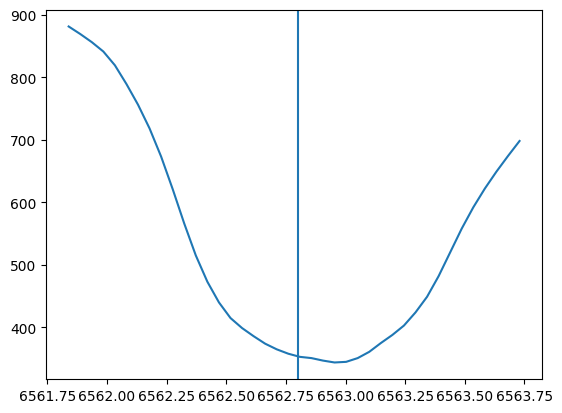

In [7]:
plt.plot(lam,spectrum)
plt.axvline(x=6562.8)

In [5]:
print(lam)

[6561.83892288 6561.88740693 6561.93589097 6561.98437501 6562.03285906
 6562.0813431  6562.12982714 6562.17831119 6562.22679523 6562.27527927
 6562.32376332 6562.37224736 6562.4207314  6562.46921545 6562.51769949
 6562.56618353 6562.61466758 6562.66315162 6562.71163566 6562.76011971
 6562.80860375 6562.85708779 6562.90557184 6562.95405588 6563.00253992
 6563.05102397 6563.09950801 6563.14799205 6563.1964761  6563.24496014
 6563.29344418 6563.34192823 6563.39041227 6563.43889631 6563.48738036
 6563.5358644  6563.58434844 6563.63283249 6563.68131653 6563.72980058]


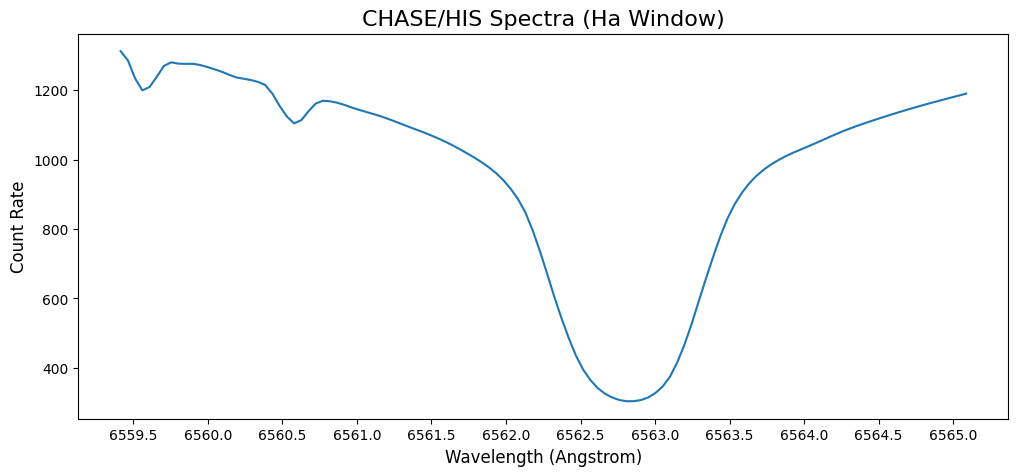

In [26]:
pix_ha = [i for i in range(118)]
wvl_ha = [rsm[1].header['CRVAL3'] + i * rsm[1].header['CDELT3'] for i in range(118)]
f_wvl = interp1d(wvl_ha, pix_ha, 'linear')
wvl_xlabel = [6559.5 + i * 0.5 for i in range(12)]
pix_xlabel = f_wvl(wvl_xlabel)

central_spec = rsm[1].data[:, 1000:1200, 1000:1200].mean((1, 2))
plt.figure(figsize = (12, 5))
plt.plot(central_spec)
plt.ylabel('Count Rate', size = 12)
plt.xlabel('Wavelength (Angstrom)', size = 12)
plt.title('CHASE/HIS Spectra (Ha Window)', size = 16)
plt.xticks(pix_xlabel, wvl_xlabel)
plt.show()

In [27]:
def pearson(vector1, vector2):
    # should have len(vector1) == len(vector2)
    n = len(vector1)

    sum1 = sum(vector1)
    sum2 = sum(vector2)

    sum1_pow = sum([pow(v, 2.0) for v in vector1])
    sum2_pow = sum([pow(v, 2.0) for v in vector2])

    p_sum = sum([vector1[i] * vector2[i] for i in range(n)])

    num = p_sum - (sum1 * sum2 / n)
    den = sqrt((sum1_pow - pow(sum1, 2) / n) * (sum2_pow - pow(sum2, 2) / n))
    if den == 0:
        return 0.0
    return num / den

def polyfit_p(x, y, n, draw = 0):
    # return para: a0, a1, a2, ..., an for y = a0 + a1 * x + a2 * x ** 2 + ... + an * x ** n
    pfpara, pfcov = np.polyfit(x, y, n, cov = True)

    if draw != 0:
        plt.subplot(211)
        lx2 = x
        ly2 = []
        for i in range(len(lx2)):
            y2 = 0
            for j in range(len(pfpara)):
                y2 += pfpara[-j - 1] * lx2[i] ** j
            ly2.append(y2)
        plt.plot(x, y, 'ro', lx2, ly2, 'b', linewidth = 2)
        plt.grid()

        plt.subplot(212)
        l0 = []
        lr = []
        for i in range(len(lx2)):
            l0.append(0)
            lr.append(y[i] - ly2[i])
        plt.plot(x, l0, 'black', linewidth = 2)
        plt.scatter(x, lr, color = 'red')
        plt.grid()

    para = list(pfpara)
    para = para[::-1]

    mat_cov = []
    for i in range(len(pfcov)):
        mat_cov.append(pfcov[-i - 1][-i - 1])

    return para, mat_cov

def cal_doppler(ij_spec, central_spec): 
    dict_c = {}
    for lag in range(-10, 11):
        ha_profilel = central_spec[lag + 50:lag + 90]  # move the ha profile, keep length
        pr = pearson(ha_profilel, ij_spec)
        dict_c[-lag] = pr

    lag_max = max(dict_c, key=lambda x: dict_c[x])
    l_lag = [lag_max - k for k in range(-2, 3)]
    l_pr = [dict_c.get(k, 0) for k in l_lag]

    para_cf, pcov_cf = polyfit_p(l_lag, l_pr, 3)
    a0, a1, a2, a3 = para_cf[0], para_cf[1], para_cf[2], para_cf[3]
    s0, s1, s2, s3 = pcov_cf[0], pcov_cf[1], pcov_cf[2], pcov_cf[3]

    discriminant = (2 * a2) ** 2 - 12 * a1 * a3

    if discriminant < 0 or a3 == 0:
        return 0.0, 0.0  # 拟合不出有效极值，返回 0

    dcf01 = (-2 * a2 + sqrt(discriminant)) / (6 * a3)
    dcf02 = (-2 * a2 - sqrt(discriminant)) / (6 * a3)

    d2cf1 = 6 * a3 * dcf01 + 2 * a2
    d2cf2 = 6 * a3 * dcf02 + 2 * a2

    covcf1_2 = s1 * (1 / discriminant) + \
        s2 * (-1 / (3 * a3) + 2 * a2 / (3 * a3 * sqrt(discriminant))) ** 2 + \
        s3 * (a2 / (3 * a3 ** 2) - (1 / (6 * a3 ** 2)) * (6 * a1 * a3 / sqrt(discriminant) + sqrt(discriminant))) ** 2

    covcf2_2 = s1 * (1 / discriminant) + \
        s2 * (-1 / (3 * a3) - 2 * a2 / (3 * a3 * sqrt(discriminant))) ** 2 + \
        s3 * (a2 / (3 * a3 ** 2) + (1 / (6 * a3 ** 2)) * (6 * a1 * a3 / sqrt(discriminant) + sqrt(discriminant))) ** 2

    if d2cf1 < 0:
        cal_shift_cf = dcf01
        cal_stddev_cf = sqrt(covcf1_2)
    else:
        cal_shift_cf = dcf02
        cal_stddev_cf = sqrt(covcf2_2)

    cal_shift_cf = 1.1068 * cal_shift_cf  # convert to km/s

    return cal_shift_cf, cal_stddev_cf


2.4398858770315006 km/s


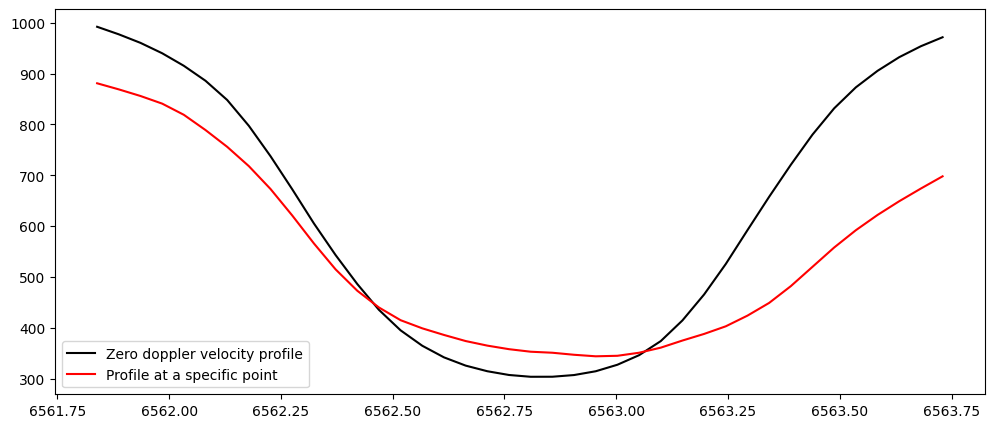

In [28]:
ij_spec = rsm[1].data[50:90,795,1521]

dict_c = {}
for lag in range(-10, 11):
    ha_profilel = central_spec[lag + 50:lag + 90] # move the ha profile, but keep the length
    pr = pearson(ha_profilel, ij_spec)
    dict_c[-lag] = pr

# use cubic fit to get the lag of the largest pearson correlation
lag_max = max(dict_c, key = lambda x:dict_c[x])
l_lag = [lag_max - k for k in range(-2, 3)]

l_pr = [dict_c[k] for k in l_lag]

para_cf, pcov_cf = polyfit_p(l_lag, l_pr, 3)

a0, a1, a2, a3 = para_cf[0], para_cf[1], para_cf[2], para_cf[3] # in format of a0 + a1 * x  + a2 * x ** 2 + a3 * x ** 3
s0, s1, s2, s3 = pcov_cf[0], pcov_cf[1], pcov_cf[2], pcov_cf[3]

dcf01 = (-2 * a2 + sqrt((2 * a2) ** 2 - 12 * a1 * a3)) / (6 * a3)
dcf02 = (-2 * a2 - sqrt((2 * a2) ** 2 - 12 * a1 * a3)) / (6 * a3)

d2cf1 = 6 * a3 * dcf01 + 2 * a2
d2cf2 = 6 * a3 * dcf02 + 2 * a2

covcf1_2 = s1 * (1 / ((2 * a2) ** 2 - 12 * a1 * a3)) + \
s2 * (-1 / (3 * a3) + 2 * a2 / (3 * a3 * sqrt((2 * a2) ** 2 - 12 * a1 * a3))) ** 2 + \
s3 * (a2 / (3 * a3 ** 2) - (1 / (6 * a3 ** 2)) * (6 * a1 * a3 / sqrt((2 * a2) ** 2 - 12 * a1 * a3) + \
sqrt((2 * a2) ** 2 - 12 * a1 * a3))) ** 2
covcf2_2 = s1 * (1 / ((2 * a2) ** 2 - 12 * a1 * a3)) + \
s2 * (-1 / (3 * a3) - 2 * a2 / (3 * a3 * sqrt((2 * a2) ** 2 - 12 * a1 * a3))) ** 2 + \
s3 * (a2 / (3 * a3 ** 2) + (1 / (6 * a3 ** 2)) * (6 * a1 * a3 / sqrt((2 * a2) ** 2 - 12 * a1 * a3) + \
sqrt((2 * a2) ** 2 - 12 * a1 * a3))) ** 2

if d2cf1 < 0:
    cal_shift_cf = dcf01
    cal_stddev_cf = sqrt(covcf1_2)
else:
    cal_shift_cf = dcf02
    cal_stddev_cf = sqrt(covcf2_2)

print(cal_shift_cf * 1.1068, 'km/s')
plt.figure(figsize = (12, 5))
plt.plot(wvl_ha[50:90], central_spec[50:90], color = 'black', label = 'Zero doppler velocity profile')
plt.plot(wvl_ha[50:90], ij_spec, color = 'red', label = 'Profile at a specific point')
plt.legend()